# Digit Recognition
Pipeline: **HOG features → SGD classifier**

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
print("ok")

ok


In [2]:
DATA_DIR = 'data'
# change for upscaling to 56x56 
IMG_BIGGER = True
IMG_SIZE = (28,28)

_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

if IMG_BIGGER:
    HOG_size = (56,56)
else:
    HOG_size = IMG_SIZE

_HOG = cv2.HOGDescriptor(_winSize=HOG_size, _blockSize=(8, 8),_blockStride=(4, 4), _cellSize=(4, 4), _nbins=9) 


def find_train_image(img_id, category):
    path = os.path.join(DATA_DIR, 'train', 'train', str(category), f'{img_id}.png')
    if os.path.exists(path):
        return path
    for cat in range(10):
        p = os.path.join(DATA_DIR, 'train', 'train', str(cat), f'{img_id}.png')
        if os.path.exists(p):
            print(f'WARNING: image {img_id} found in class {cat}, expected class {category}')
            return p
    return None

def find_test_image(img_id):
    for candidate in [
        os.path.join(DATA_DIR, 'test', f'{img_id}.png'),
        *[os.path.join(DATA_DIR, 'test', 'test', str(c), f'{img_id}.png') for c in range(10)],
        os.path.join(DATA_DIR, 'test', 'test', f'{img_id}.png'),
    ]:
        if os.path.exists(candidate):
            return candidate
    return None

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'cv2.imread failed to load image: {path}')
    return cv2.resize(img, IMG_SIZE)

def preprocess(path):
    img = _CLAHE.apply(load_image(path))
    return _HOG.compute(img).flatten()

def preprocess_upscaled(img):
    img_up = cv2.resize(img,(56, 56),interpolation=cv2.INTER_CUBIC)
    img_up = cv2.GaussianBlur(img_up, (3, 3), 0)
    IMG_BIGGER = True
    return img_up

## Sample Images

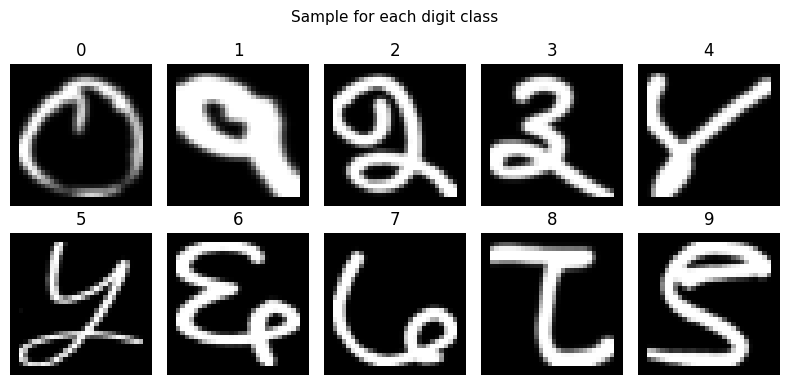

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
fig.suptitle('Sample for each digit class', fontsize=11)

for digit, ax in enumerate(axes.flat):
    row = train_df[train_df['Category'] == digit].iloc[0]
    path = find_train_image(row['Id'], row['Category'])
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(str(digit), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Load Training Data

17000 samples  HOG: 6084  raw: (56, 56)  0 missing


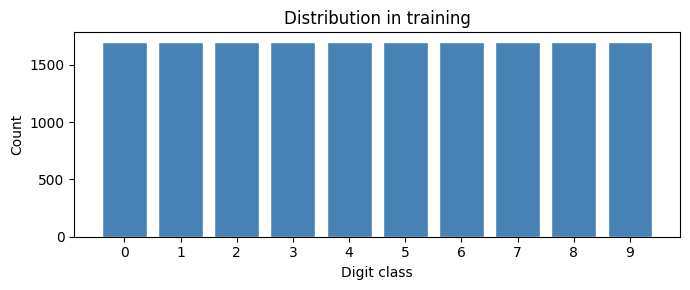

In [4]:
X_train, X_train_raw, y_train = [], [], []
missing = 0

for _, row in train_df.iterrows():
    path = find_train_image(row['Id'], row['Category'])
    if path is None:
        missing += 1
        continue
    img = load_image(path)
    img = preprocess_upscaled(img)
    X_train_raw.append(img)
    X_train.append(_HOG.compute(_CLAHE.apply(img)).flatten())
    y_train.append(int(row['Category']))

X_train     = np.array(X_train)
X_train_raw = np.array(X_train_raw, dtype=np.uint8)
y_train     = np.array(y_train)
print(f'{len(X_train)} samples  HOG: {X_train.shape[1]}  raw: {X_train_raw.shape[1:]}  {missing} missing')

fig, ax = plt.subplots(figsize=(7, 3))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Digit class'); ax.set_ylabel('Count')
ax.set_title('Distribution in training')
ax.set_xticks(unique)
plt.tight_layout(); plt.show()



## Train Classifier

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

MODEL_PATH = 'model.joblib'

indices = np.arange(len(y_train))
idx_tr, idx_val = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_train
)
X_tr,     X_val     = X_train[idx_tr],     X_train[idx_val]
X_tr_raw, X_val_raw = X_train_raw[idx_tr], X_train_raw[idx_val]
y_tr,     y_val     = y_train[idx_tr],     y_train[idx_val]

if os.path.exists(MODEL_PATH):
    print('Loading saved model — skipping training')
    clf = joblib.load(MODEL_PATH)
    train_acc = np.mean(clf.predict(X_tr) == y_tr)
    val_acc   = np.mean(clf.predict(X_val) == y_val)
    print(f'Loaded  train: {train_acc:.2%}  val: {val_acc:.2%}')
else:
    candidates = {
        'SGD (linear)':  Pipeline([('scaler', StandardScaler()), ('clf', SGDClassifier(loss='hinge', max_iter=50000, early_stopping=True, random_state=42, n_jobs=-1))]),
        'SVC (RBF)':     GridSearchCV(
                             Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', random_state=42))]),
                             {'clf__C': [1, 10, 100], 'clf__gamma': ['scale', 0.01, 0.001]},
                             cv=3, n_jobs=-1
                         ),
        'Random Forest': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
    }

    results = {}
    for name, pipeline in candidates.items():
        pipeline.fit(X_tr, y_tr)
        tr_acc = np.mean(pipeline.predict(X_tr) == y_tr)
        v_acc  = np.mean(pipeline.predict(X_val) == y_val)
        results[name] = {'model': pipeline, 'train_acc': tr_acc, 'val_acc': v_acc}
        print(f'{name:20s}  train: {tr_acc:.2%}  val: {v_acc:.2%}')

    best_name = max(results, key=lambda k: results[k]['val_acc'])
    clf       = results[best_name]['model']
    train_acc = results[best_name]['train_acc']
    val_acc   = results[best_name]['val_acc']
    print(f'\nBest sklearn: {best_name}  (val {val_acc:.2%})')
    joblib.dump(clf, MODEL_PATH)
    print(f'Saved to {MODEL_PATH}')

cv_model  = clf.best_estimator_ if hasattr(clf, 'best_estimator_') else clf
cv_scores = cross_val_score(cv_model, X_train, y_train, cv=5, n_jobs=-1)
print(f'\nCross-validation (5-fold): {cv_scores.mean():.2%} +/- {cv_scores.std():.2%}')

use_raw_for_predict = False

SGD (linear)          train: 99.78%  val: 98.59%
SVC (RBF)             train: 100.00%  val: 99.29%
Random Forest         train: 100.00%  val: 98.56%

Best sklearn: SVC (RBF)  (val 99.29%)
Saved to model.joblib

Cross-validation (5-fold): 99.52% +/- 0.12%


## CNN with Augmentation
A small convolutional network trained on raw images with random affine augmentation.
This typically beats HOG+SVM on MNIST-style data.

In [7]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms as T
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print('PyTorch not installed — skipping CNN. Install with: pip install torch torchvision')

if HAS_TORCH:
    class _CNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
            self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
            if IMG_BIGGER:
                self.fc1 = nn.Linear(64 * 14 * 14, 128)
            else:
                self.fc1 = nn.Linear(64 * 7 * 7, 128)

            self.fc2   = nn.Linear(128, 10)
            self.drop  = nn.Dropout(0.5)

        def forward(self, x):
            x = F.max_pool2d(F.relu(self.conv1(x)), 2)
            x = F.max_pool2d(F.relu(self.conv2(x)), 2)
            x = x.flatten(1)
            x = F.relu(self.fc1(x))
            return self.fc2(self.drop(x))

    class _AugDataset(Dataset):
        def __init__(self, X, y, augment):
            self.X, self.y = X, y
            steps = [T.ToPILImage()]
            if augment:
                steps.append(T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)))
            steps.append(T.ToTensor())
            self.tf = T.Compose(steps)
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.tf(self.X[i]), int(self.y[i])

    class TorchCNN:
        def __init__(self, epochs=15, batch_size=128, lr=1e-3):
            self.epochs, self.batch_size, self.lr = epochs, batch_size, lr
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            self.model  = None

        def fit(self, X, y, X_val=None, y_val=None):
            self.model = _CNN().to(self.device)
            opt  = torch.optim.Adam(self.model.parameters(), lr=self.lr)
            crit = nn.CrossEntropyLoss()
            loader = DataLoader(_AugDataset(X, y, augment=True),
                                batch_size=self.batch_size, shuffle=True)
            for ep in range(self.epochs):
                self.model.train()
                for xb, yb in loader:
                    xb, yb = xb.to(self.device), yb.to(self.device)
                    opt.zero_grad()
                    crit(self.model(xb), yb).backward()
                    opt.step()
                if X_val is not None:
                    v = (self.predict(X_val) == y_val).mean()
                    print(f'  Epoch {ep+1:2d}/{self.epochs}  val: {v:.2%}')
            return self

        def predict(self, X):
            self.model.eval()
            loader = DataLoader(_AugDataset(X, np.zeros(len(X)), augment=False),
                                batch_size=256, shuffle=False)
            preds = []
            with torch.no_grad():
                for xb, _ in loader:
                    preds.append(self.model(xb.to(self.device)).argmax(1).cpu().numpy())
            return np.concatenate(preds)

    CNN_PATH = 'cnn_model.pt'
    cnn = TorchCNN(epochs=15)

    if os.path.exists(CNN_PATH):
        print('Loading saved CNN...')
        cnn.model = _CNN().to(cnn.device)
        cnn.model.load_state_dict(torch.load(CNN_PATH, map_location=cnn.device))
    else:
        print(f'Training CNN on {cnn.device}...')
        cnn.fit(X_tr_raw, y_tr, X_val_raw, y_val)
        torch.save(cnn.model.state_dict(), CNN_PATH)
        print(f'Saved CNN to {CNN_PATH}')

    cnn_train_acc = (cnn.predict(X_tr_raw) == y_tr).mean()
    cnn_val_acc   = (cnn.predict(X_val_raw) == y_val).mean()
    print(f'\nCNN  train: {cnn_train_acc:.2%}  val: {cnn_val_acc:.2%}')

    if cnn_val_acc > val_acc:
        print(f'CNN beats sklearn ({cnn_val_acc:.2%} > {val_acc:.2%}) — using CNN for submission')
        clf, train_acc, val_acc = cnn, cnn_train_acc, cnn_val_acc
        use_raw_for_predict = True
        betterModel = "cnn"
    else:
        betterModel = "sklearn"
        print(f'Sklearn still wins ({val_acc:.2%} >= {cnn_val_acc:.2%}) — keeping sklearn for submission')

Training CNN on cpu...
  Epoch  1/15  val: 93.79%
  Epoch  2/15  val: 98.18%
  Epoch  3/15  val: 98.71%
  Epoch  4/15  val: 98.82%
  Epoch  5/15  val: 99.18%
  Epoch  6/15  val: 99.12%
  Epoch  7/15  val: 99.09%
  Epoch  8/15  val: 99.06%
  Epoch  9/15  val: 99.15%
  Epoch 10/15  val: 99.26%
  Epoch 11/15  val: 99.26%
  Epoch 12/15  val: 99.21%
  Epoch 13/15  val: 99.35%
  Epoch 14/15  val: 99.41%
  Epoch 15/15  val: 99.44%
Saved CNN to cnn_model.pt

CNN  train: 99.68%  val: 99.44%
CNN beats sklearn (99.44% > 99.29%) — using CNN for submission


## Evaluation — Confusion Matrix

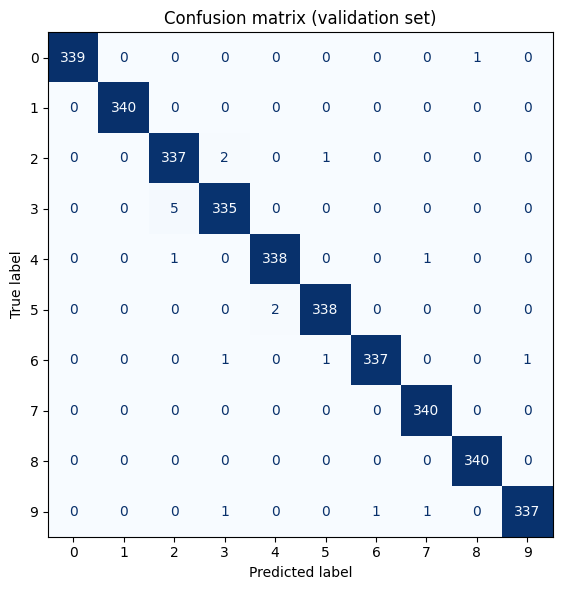

              precision    recall  f1-score   support

           0     1.0000    0.9971    0.9985       340
           1     1.0000    1.0000    1.0000       340
           2     0.9825    0.9912    0.9868       340
           3     0.9882    0.9853    0.9867       340
           4     0.9941    0.9941    0.9941       340
           5     0.9941    0.9941    0.9941       340
           6     0.9970    0.9912    0.9941       340
           7     0.9942    1.0000    0.9971       340
           8     0.9971    1.0000    0.9985       340
           9     0.9970    0.9912    0.9941       340

    accuracy                         0.9944      3400
   macro avg     0.9944    0.9944    0.9944      3400
weighted avg     0.9944    0.9944    0.9944      3400



In [8]:

X_eval = X_val_raw if use_raw_for_predict else X_val
preds_val = clf.predict(X_eval)


cm = confusion_matrix(y_val, preds_val)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix (validation set)')
plt.tight_layout(); plt.show()

print(classification_report(y_val, preds_val, digits=4))

## Predict Test Set

Saved 3000 to submission.csv
Validation acc: 99.44%


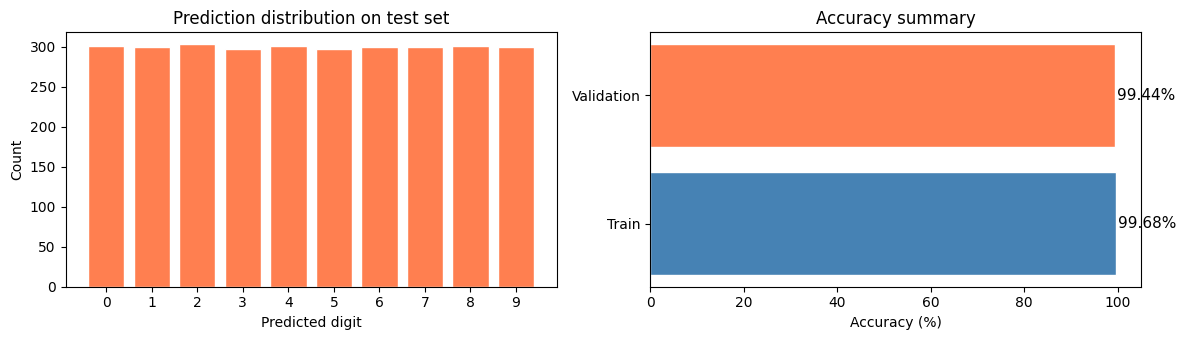

In [10]:
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

test_ids, test_paths = [], []
for img_id in test_df['Id']:
    path = find_test_image(img_id)
    if path is None:
        print(f'WARNING: test image {img_id} not found — skipping (will not appear in submission)')
        continue
    test_ids.append(img_id)
    test_paths.append(path)

if use_raw_for_predict:
    if IMG_BIGGER:
        test_X = np.array([
            preprocess_upscaled(load_image(p)) for p in test_paths
        ], dtype=np.uint8)
    else:
        test_X = np.array([
            load_image(p) for p in test_paths
        ], dtype=np.uint8)
else:
    test_X = np.array([
        preprocess(p) for p in test_paths
    ])

predictions = clf.predict(test_X)

submission = pd.DataFrame({'Id': test_ids, 'Category': predictions})
submission.to_csv('submission.csv', index=False)
print(f'Saved {len(submission)} to submission.csv')
print(f'Validation acc: {val_acc:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

unique, counts = np.unique(predictions, return_counts=True)
axes[0].bar(unique, counts, color='coral', edgecolor='white')
axes[0].set_xlabel('Predicted digit'); axes[0].set_ylabel('Count')
axes[0].set_title('Prediction distribution on test set')
axes[0].set_xticks(unique)

axes[1].barh(['Train', 'Validation'], [train_acc * 100, val_acc * 100],
             color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_xlim(0, 105)
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_title('Accuracy summary')
for i, v in enumerate([train_acc, val_acc]):
    axes[1].text(v * 100 + 0.5, i, f'{v:.2%}', va='center', fontsize=11)

plt.tight_layout(); plt.show()

## Train on all data

In [ ]:
from sklearn.base import clone
NEW_MODEL_PATH = 'new_model.joblib'
NEW_CNN_PATH   = 'new_cnn_weights.pth'

if betterModel == "cnn":

    if os.path.exists(NEW_CNN_PATH):
        print('Loading retrained CNN — skipping training')
        new_clf = TorchCNN(
            epochs=30,
            batch_size=128,
            lr=1e-3
        )
        new_clf.model.load_state_dict(
            torch.load(NEW_CNN_PATH))
    else:
        print('Training retrained CNN on full dataset')

        new_clf = TorchCNN(
            epochs=30,
            batch_size=128,
            lr=1e-3
        )

        new_clf.fit(X_train_raw, y_train)

        torch.save(new_clf.model.state_dict(), NEW_CNN_PATH)
        print(f'Saved retrained CNN to {NEW_CNN_PATH}')
else:

    if os.path.exists(NEW_MODEL_PATH):
        print('Loading retrained sklearn model — skipping training')

        new_clf = joblib.load(NEW_MODEL_PATH)

    else:
        print('Training retrained sklearn model on full dataset')

        from sklearn.base import clone

        final_model = (
            clf.best_estimator_
            if hasattr(clf, 'best_estimator_')
            else clf
        )

        new_clf = clone(final_model)
        new_clf.fit(X_train, y_train)

        joblib.dump(new_clf, NEW_MODEL_PATH)

        print(f'Saved retrained sklearn model to {NEW_MODEL_PATH}')

## Testing final model

In [ ]:
new_test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

new_test_ids = []
new_test_paths = []

for new_img_id in new_test_df['Id']:
    new_path = find_test_image(new_img_id)

    if new_path is None:
        print(f'WARNING: test image {new_img_id} not found — skipping')
        continue

    new_test_ids.append(new_img_id)
    new_test_paths.append(new_path)

if betterModel == "cnn":
    new_test_X = np.array([load_image(p) for p in new_test_paths], dtype=np.uint8)

    new_validation_predictions = new_cnn.predict(X_val_raw)
    new_predictions = new_cnn.predict(new_test_X)

else:
    new_test_X = np.array([preprocess(p) for p in new_test_paths])

    new_validation_predictions = new_clf.predict(X_val)
    new_predictions = new_clf.predict(new_test_X)

new_validation_accuracy = np.mean(new_validation_predictions == y_val)

print(f'Final model validation accuracy: {new_validation_accuracy:.2%}')

new_submission = pd.DataFrame({
    'Id': new_test_ids,
    'Category': new_predictions
})

new_submission.to_csv('submission_final_model.csv', index=False)

print(f'Saved {len(new_submission)} rows to submission_final_model.csv')

new_unique_labels, new_label_counts = np.unique(new_predictions, return_counts=True)

plt.figure(figsize=(8, 3.5))
plt.bar(new_unique_labels, new_label_counts)
plt.xlabel('Predicted digit')
plt.ylabel('Count')
plt.title('Final model prediction distribution on test set')
plt.xticks(new_unique_labels)
plt.tight_layout()
plt.show()